# 03 — Distribution Shift Analysis
**Project:** ViT Reliability & Explainability Under Medical Distribution Shift
**Author:** Sosna Worku

**Continues from:** `02_baseline_training.ipynb`
- ViT Mean AUC (ID): 0.800
- ResNet Mean AUC (ID): 0.745
- Checkpoints saved in Google Drive

**Goal:** Evaluate both models on CheXpert (OOD). Measure AUC drop, calibration degradation, MC-Dropout uncertainty.

**Research Questions:**
- RQ1: How much does performance drop under distribution shift?
- RQ2: Does uncertainty estimation flag OOD failures?

---
Run all cells top to bottom every new Colab session.

## 0. Setup — Run every session

In [2]:
import os, sys

REPO_PATH = '/content/vit-medical-shift'
GITHUB    = 'https://github.com/sossyh/vit-medical-shift.git'

if os.path.exists(REPO_PATH):
    os.system(f'git -C {REPO_PATH} pull origin main')
else:
    os.system(f'git clone {GITHUB} {REPO_PATH}')

sys.path.insert(0, REPO_PATH)
print('Repo ready!')

Repo ready!


In [8]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


In [9]:
!pip install -q timm torchmetrics grad-cam einops pyyaml
print('Packages ready!')

Packages ready!


In [10]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

GPU: Tesla T4


## 1. Paths & Device

In [11]:
from src.utils import get_device, set_seed

set_seed(42)
device = get_device()

# NIH paths (in-distribution)
NIH_CSV   = '/content/drive/MyDrive/data/nih/Data_Entry_2017.csv'
NIH_IMGS  = '/content/drive/MyDrive/data/nih/images'

# CheXpert paths (OOD)
CHEX_CSV  = '/content/drive/MyDrive/data/chexpert/valid.csv'
CHEX_IMGS = '/content/drive/MyDrive/data/chexpert/PNG_valid_files'

# Checkpoints from notebook 02
VIT_CKPT    = '/content/drive/MyDrive/checkpoints/vit_nih/best.pth'
RESNET_CKPT = '/content/drive/MyDrive/checkpoints/resnet_nih/best.pth'

print('ViT checkpoint   :', os.path.exists(VIT_CKPT))
print('ResNet checkpoint:', os.path.exists(RESNET_CKPT))
print('CheXpert CSV     :', os.path.exists(CHEX_CSV))
print('CheXpert images  :', os.path.exists(CHEX_IMGS))

Using GPU: Tesla T4
ViT checkpoint   : True
ResNet checkpoint: True
CheXpert CSV     : True
CheXpert images  : True


## 2. Copy NIH Images to Local Disk

In [12]:
# Skip local copy — read directly from Drive
# Only doing validation (one forward pass), not training
NIH_IMGS = '/content/drive/MyDrive/data/nih/images'
print('NIH images dir:', NIH_IMGS)
print('Accessible:', os.path.exists(NIH_IMGS))

NIH images dir: /content/drive/MyDrive/data/nih/images
Accessible: True


## 3. Load Models from Checkpoints (no retraining!)

In [13]:
from src.model import get_vit, get_resnet

# Load ViT
vit_model = get_vit(num_classes=14, pretrained=False).to(device)
vit_model.load_state_dict(torch.load(VIT_CKPT, map_location=device))
vit_model.eval()
print('ViT loaded from checkpoint!')

# Load ResNet
resnet_model = get_resnet(num_classes=14, pretrained=False).to(device)
resnet_model.load_state_dict(torch.load(RESNET_CKPT, map_location=device))
resnet_model.eval()
print('ResNet loaded from checkpoint!')

ViT loaded from checkpoint!
ResNet loaded from checkpoint!


## 4. Load NIH Validation Set (In-Distribution)

In [14]:
from src.dataset import get_nih_loaders

_, val_loader_id = get_nih_loaders(
    csv_path    = NIH_CSV,
    img_dir     = NIH_IMGS,
    batch_size  = 32,
    subset      = 0.2,
    num_workers = 0
)
print(f'NIH val batches : {len(val_loader_id)}')
print(f'NIH val images  : {len(val_loader_id.dataset):,}')

Filtering to available images...
Available: 94,875 / 112,120
Filtering to available images...
Available: 94,875 / 112,120
Filtering to available images...
Available: 94,875 / 112,120
NIH val batches : 119
NIH val images  : 3,795


## 5. Load CheXpert Validation Set (Out-of-Distribution)

In [15]:
from src.dataset import CheXpertDataset, get_transforms
from torch.utils.data import DataLoader

chex_dataset = CheXpertDataset(
    csv_path  = CHEX_CSV,
    img_root  = CHEX_IMGS,
    transform = get_transforms('val')
)
chex_loader = DataLoader(
    chex_dataset, batch_size=32,
    shuffle=False, num_workers=0
)
print(f'CheXpert samples: {len(chex_dataset)}')

CheXpert available: 202 images
CheXpert samples: 202


## 6. ID Evaluation (NIH)

In [16]:
import torch.nn as nn
from src.evaluate import compute_auc, compute_ece, print_metrics
from src.train import validate

criterion = nn.BCEWithLogitsLoss()

print('--- ViT ID (NIH) ---')
_, vit_logits_id, vit_labels_id = validate(vit_model, val_loader_id, criterion, device)
vit_auc_id = compute_auc(vit_logits_id, vit_labels_id)
vit_ece_id = compute_ece(vit_logits_id, vit_labels_id)
print_metrics(vit_auc_id, vit_ece_id, 'ViT ID')

print('\n--- ResNet ID (NIH) ---')
_, res_logits_id, res_labels_id = validate(resnet_model, val_loader_id, criterion, device)
res_auc_id = compute_auc(res_logits_id, res_labels_id)
res_ece_id = compute_ece(res_logits_id, res_labels_id)
print_metrics(res_auc_id, res_ece_id, 'ResNet ID')

--- ViT ID (NIH) ---



[ViT ID] Mean AUC : 0.8006
[ViT ID] ECE      : 0.0059

Per-class AUC:
  Atelectasis            0.7764
  Cardiomegaly           0.8692
  Effusion               0.8546
  Infiltration           0.7116
  Mass                   0.7871
  Nodule                 0.7124
  Pneumonia              0.7447
  Pneumothorax           0.8466
  Consolidation          0.8032
  Edema                  0.8854
  Emphysema              0.9100
  Fibrosis               0.7987
  Pleural_Thickening     0.7334
  Hernia                 0.7749

--- ResNet ID (NIH) ---



[ResNet ID] Mean AUC : 0.7455
[ResNet ID] ECE      : 0.0027

Per-class AUC:
  Atelectasis            0.7530
  Cardiomegaly           0.7275
  Effusion               0.8342
  Infiltration           0.6989
  Mass                   0.7215
  Nodule                 0.6769
  Pneumonia              0.6879
  Pneumothorax           0.7726
  Consolidation          0.8074
  Edema                  0.8691
  Emphysema              0.8340
  Fibrosis               0.7196
  Pleural_Thickening     0.6881
  Hernia                 0.6458


## 7. OOD Evaluation (CheXpert) — Core Result!

In [17]:
print('--- ViT OOD (CheXpert) ---')
_, vit_logits_ood, vit_labels_ood = validate(vit_model, chex_loader, criterion, device)
vit_auc_ood = compute_auc(vit_logits_ood, vit_labels_ood)
vit_ece_ood = compute_ece(vit_logits_ood, vit_labels_ood)
print_metrics(vit_auc_ood, vit_ece_ood, 'ViT OOD')

print('\n--- ResNet OOD (CheXpert) ---')
_, res_logits_ood, res_labels_ood = validate(resnet_model, chex_loader, criterion, device)
res_auc_ood = compute_auc(res_logits_ood, res_labels_ood)
res_ece_ood = compute_ece(res_logits_ood, res_labels_ood)
print_metrics(res_auc_ood, res_ece_ood, 'ResNet OOD')

--- ViT OOD (CheXpert) ---



[ViT OOD] Mean AUC : 0.7738
[ViT OOD] ECE      : 0.0401

Per-class AUC:
  Atelectasis            0.7667
  Cardiomegaly           0.7904
  Effusion               0.8855
  Infiltration           N/A
  Mass                   N/A
  Nodule                 N/A
  Pneumonia              0.6978
  Pneumothorax           0.6198
  Consolidation          0.8204
  Edema                  0.8362
  Emphysema              N/A
  Fibrosis               N/A
  Pleural_Thickening     N/A
  Hernia                 N/A

--- ResNet OOD (CheXpert) ---



[ResNet OOD] Mean AUC : 0.7291
[ResNet OOD] ECE      : 0.0349

Per-class AUC:
  Atelectasis            0.7419
  Cardiomegaly           0.6369
  Effusion               0.8361
  Infiltration           N/A
  Mass                   N/A
  Nodule                 N/A
  Pneumonia              0.6218
  Pneumothorax           0.6652
  Consolidation          0.7785
  Edema                  0.8233
  Emphysema              N/A
  Fibrosis               N/A
  Pleural_Thickening     N/A
  Hernia                 N/A


## 8. Distribution Shift Summary Table

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils import NIH_LABELS

# Build shift table
shift_df = pd.DataFrame({
    'Label'      : NIH_LABELS + ['Mean'],
    'ViT ID'     : [vit_auc_id[l]  for l in NIH_LABELS] + [vit_auc_id['mean']],
    'ViT OOD'    : [vit_auc_ood[l] for l in NIH_LABELS] + [vit_auc_ood['mean']],
    'ResNet ID'  : [res_auc_id[l]  for l in NIH_LABELS] + [res_auc_id['mean']],
    'ResNet OOD' : [res_auc_ood[l] for l in NIH_LABELS] + [res_auc_ood['mean']],
})
shift_df['ViT Drop']    = shift_df['ViT ID']    - shift_df['ViT OOD']
shift_df['ResNet Drop'] = shift_df['ResNet ID'] - shift_df['ResNet OOD']
print(shift_df.to_string(index=False))

# Summary stats
print(f'\nViT   Mean AUC drop : {shift_df["ViT Drop"].iloc[-1]:.4f}')
print(f'ResNet Mean AUC drop: {shift_df["ResNet Drop"].iloc[-1]:.4f}')
print(f'\nECE ID  → OOD:')
print(f'  ViT   : {vit_ece_id:.4f} → {vit_ece_ood:.4f}')
print(f'  ResNet: {res_ece_id:.4f} → {res_ece_ood:.4f}')

             Label   ViT ID  ViT OOD  ResNet ID  ResNet OOD  ViT Drop  ResNet Drop
       Atelectasis 0.776423 0.766719   0.752955    0.741942  0.009704     0.011013
      Cardiomegaly 0.869244 0.790441   0.727530    0.636921  0.078803     0.090610
          Effusion 0.854593 0.885530   0.834226    0.836051 -0.030937    -0.001825
      Infiltration 0.711618      NaN   0.698936         NaN       NaN          NaN
              Mass 0.787120      NaN   0.721490         NaN       NaN          NaN
            Nodule 0.712365      NaN   0.676930         NaN       NaN          NaN
         Pneumonia 0.744680 0.697809   0.687912    0.621778  0.046871     0.066134
      Pneumothorax 0.846554 0.619780   0.772591    0.665201  0.226773     0.107390
     Consolidation 0.803201 0.820404   0.807424    0.778493 -0.017204     0.028932
             Edema 0.885404 0.836161   0.869054    0.823289  0.049243     0.045766
         Emphysema 0.910000      NaN   0.833967         NaN       NaN          NaN
    

## 9. Plot AUC Drop

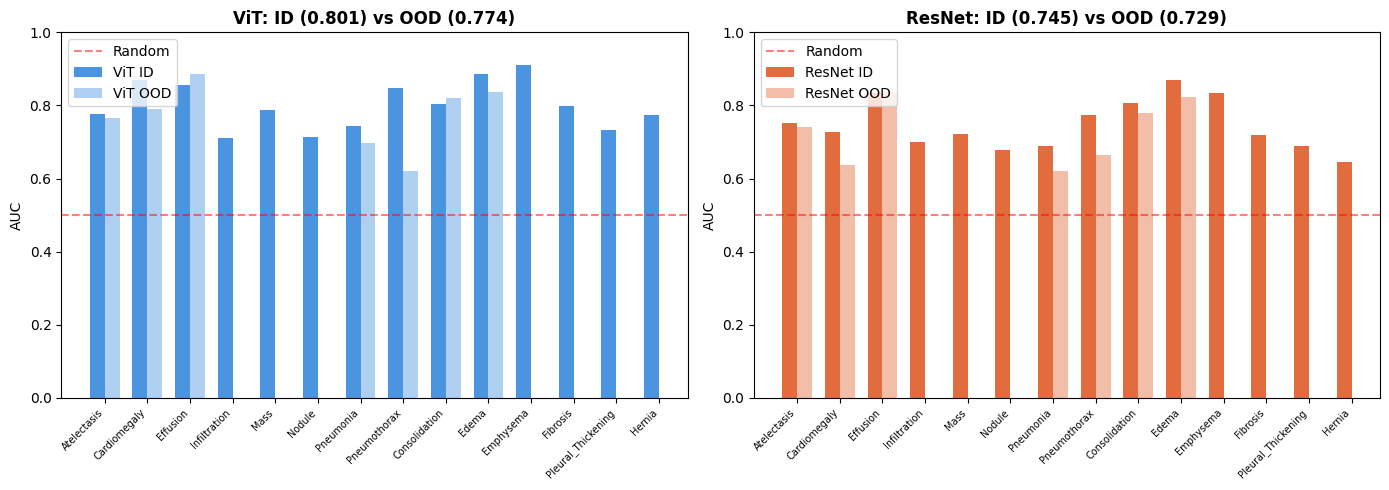

Saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(NIH_LABELS))
w = 0.35

# ViT ID vs OOD
axes[0].bar([i-w/2 for i in x], [vit_auc_id[l]  for l in NIH_LABELS], w,
            label='ViT ID',  color='#378ADD', alpha=0.9)
axes[0].bar([i+w/2 for i in x], [vit_auc_ood[l] for l in NIH_LABELS], w,
            label='ViT OOD', color='#378ADD', alpha=0.4)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(NIH_LABELS, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('AUC')
axes[0].set_title(f'ViT: ID ({vit_auc_id["mean"]:.3f}) vs OOD ({vit_auc_ood["mean"]:.3f})', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# ResNet ID vs OOD
axes[1].bar([i-w/2 for i in x], [res_auc_id[l]  for l in NIH_LABELS], w,
            label='ResNet ID',  color='#E05C2A', alpha=0.9)
axes[1].bar([i+w/2 for i in x], [res_auc_ood[l] for l in NIH_LABELS], w,
            label='ResNet OOD', color='#E05C2A', alpha=0.4)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(NIH_LABELS, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('AUC')
axes[1].set_title(f'ResNet: ID ({res_auc_id["mean"]:.3f}) vs OOD ({res_auc_ood["mean"]:.3f})', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
os.makedirs(f'{REPO_PATH}/results/figures', exist_ok=True)
plt.savefig(f'{REPO_PATH}/results/figures/distribution_shift_auc.png', dpi=150)
plt.show()
print('Saved!')

## 10. Calibration — Reliability Diagrams ID vs OOD

Saved → /content/vit-medical-shift/results/figures/reliability_vit_id.png


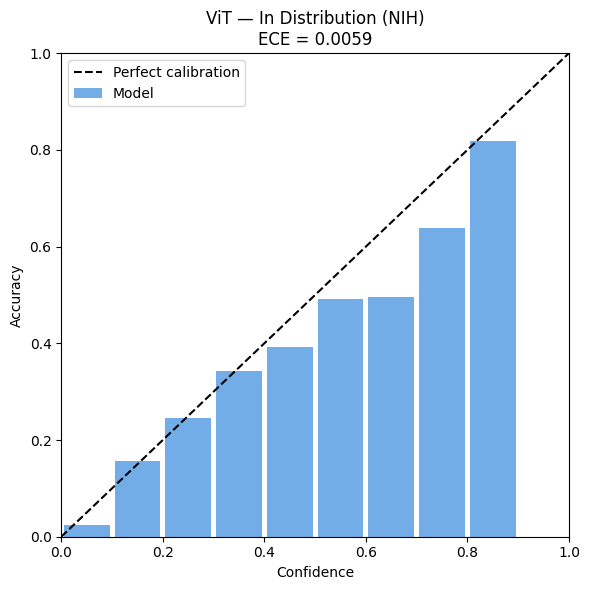

Saved → /content/vit-medical-shift/results/figures/reliability_vit_ood.png


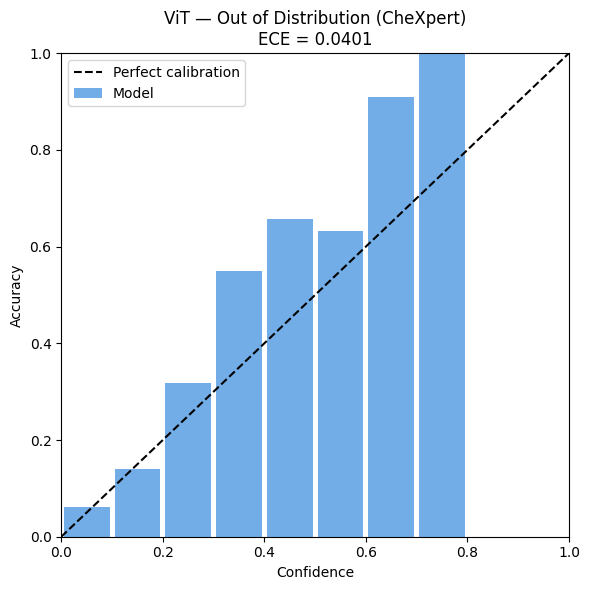

Saved → /content/vit-medical-shift/results/figures/reliability_resnet_id.png


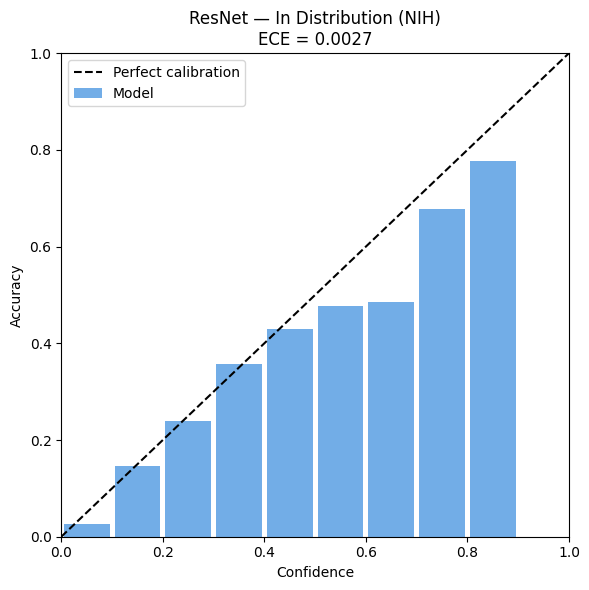

Saved → /content/vit-medical-shift/results/figures/reliability_resnet_ood.png


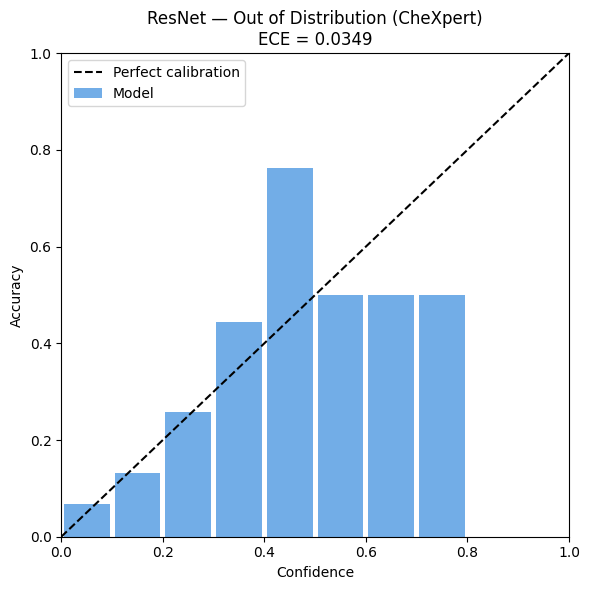

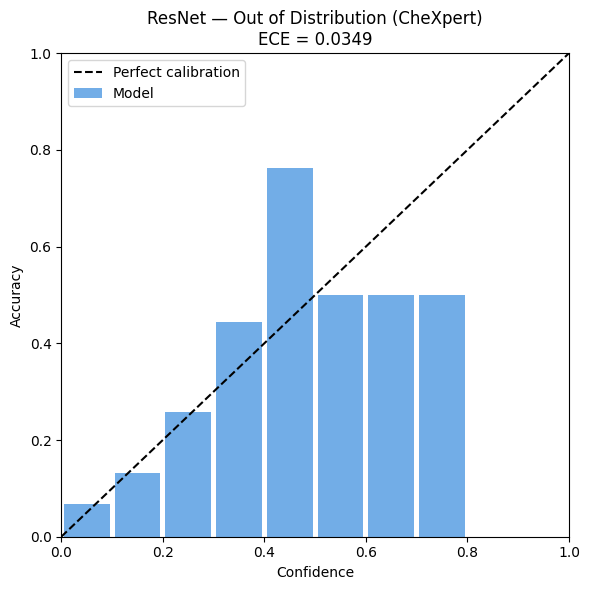

In [21]:
from src.evaluate import plot_reliability_diagram

plot_reliability_diagram(
    vit_logits_id, vit_labels_id,
    title='ViT — In Distribution (NIH)',
    save_path=f'{REPO_PATH}/results/figures/reliability_vit_id.png'
)
plot_reliability_diagram(
    vit_logits_ood, vit_labels_ood,
    title='ViT — Out of Distribution (CheXpert)',
    save_path=f'{REPO_PATH}/results/figures/reliability_vit_ood.png'
)
plot_reliability_diagram(
    res_logits_id, res_labels_id,
    title='ResNet — In Distribution (NIH)',
    save_path=f'{REPO_PATH}/results/figures/reliability_resnet_id.png'
)
plot_reliability_diagram(
    res_logits_ood, res_labels_ood,
    title='ResNet — Out of Distribution (CheXpert)',
    save_path=f'{REPO_PATH}/results/figures/reliability_resnet_ood.png'
)

## 11. MC-Dropout Uncertainty — ID vs OOD

ViT uncertainty ID     : 0.0061
ViT uncertainty OOD    : 0.0056
ResNet uncertainty ID  : 0.0000
ResNet uncertainty OOD : 0.0000

Higher OOD uncertainty = model knows it is uncertain = good!


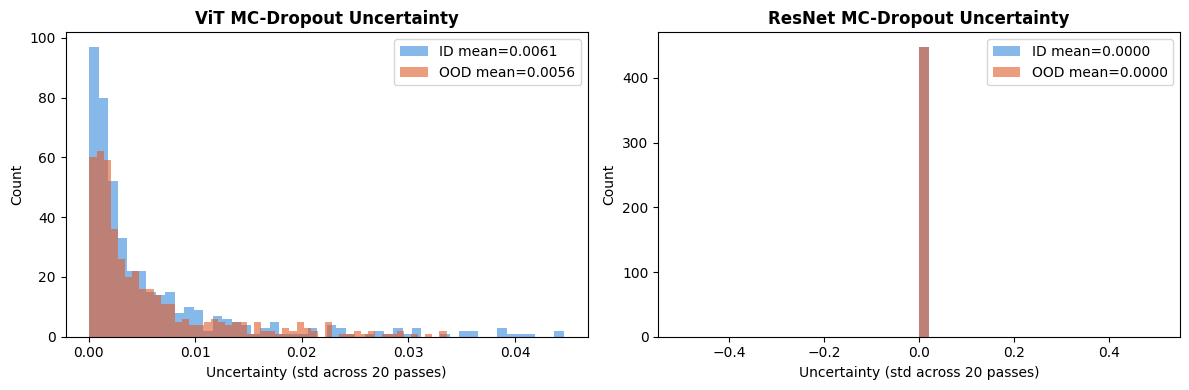

Saved!


In [23]:
from src.model import mc_dropout_predict

# Get one batch from each domain
id_images,  _, _ = next(iter(val_loader_id))
ood_images, _, _ = next(iter(chex_loader))

# Run 20 stochastic forward passes
vit_mean_id,  vit_std_id  = mc_dropout_predict(vit_model, id_images,  n_passes=20, device=device)
vit_mean_ood, vit_std_ood = mc_dropout_predict(vit_model, ood_images, n_passes=20, device=device)

res_mean_id,  res_std_id  = mc_dropout_predict(resnet_model, id_images,  n_passes=20, device=device)
res_mean_ood, res_std_ood = mc_dropout_predict(resnet_model, ood_images, n_passes=20, device=device)

print(f'ViT uncertainty ID     : {vit_std_id.mean().item():.4f}')
print(f'ViT uncertainty OOD    : {vit_std_ood.mean().item():.4f}')
print(f'ResNet uncertainty ID  : {res_std_id.mean().item():.4f}')
print(f'ResNet uncertainty OOD : {res_std_ood.mean().item():.4f}')
print('\nHigher OOD uncertainty = model knows it is uncertain = good!')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vit_std_id.numpy().flatten(),  bins=50, alpha=0.6,
             color='#378ADD', label=f'ID mean={vit_std_id.mean():.4f}')
axes[0].hist(vit_std_ood.numpy().flatten(), bins=50, alpha=0.6,
             color='#E05C2A', label=f'OOD mean={vit_std_ood.mean():.4f}')
axes[0].set_xlabel('Uncertainty (std across 20 passes)')
axes[0].set_ylabel('Count')
axes[0].set_title('ViT MC-Dropout Uncertainty', fontweight='bold')
axes[0].legend()

axes[1].hist(res_std_id.numpy().flatten(),  bins=50, alpha=0.6,
             color='#378ADD', label=f'ID mean={res_std_id.mean():.4f}')
axes[1].hist(res_std_ood.numpy().flatten(), bins=50, alpha=0.6,
             color='#E05C2A', label=f'OOD mean={res_std_ood.mean():.4f}')
axes[1].set_xlabel('Uncertainty (std across 20 passes)')
axes[1].set_ylabel('Count')
axes[1].set_title('ResNet MC-Dropout Uncertainty', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REPO_PATH}/results/figures/mc_dropout_uncertainty.png', dpi=150)
plt.show()
print('Saved!')

## 12. Save Results & Download

In [24]:
import json
from google.colab import files

os.makedirs(f'{REPO_PATH}/results/metrics', exist_ok=True)

# Save shift metrics
shift_metrics = {
    'vit': {
        'id_auc' : vit_auc_id,
        'ood_auc': vit_auc_ood,
        'id_ece' : vit_ece_id,
        'ood_ece': vit_ece_ood
    },
    'resnet': {
        'id_auc' : res_auc_id,
        'ood_auc': res_auc_ood,
        'id_ece' : res_ece_id,
        'ood_ece': res_ece_ood
    }
}
with open(f'{REPO_PATH}/results/metrics/shift_metrics.json', 'w') as f:
    json.dump(shift_metrics, f, indent=2)

shift_df.to_csv(f'{REPO_PATH}/results/metrics/shift_analysis.csv', index=False)
print('Metrics saved! Downloading...')

# Download to Mac
files.download(f'{REPO_PATH}/results/metrics/shift_metrics.json')
files.download(f'{REPO_PATH}/results/metrics/shift_analysis.csv')
files.download(f'{REPO_PATH}/results/figures/distribution_shift_auc.png')
files.download(f'{REPO_PATH}/results/figures/reliability_vit_id.png')
files.download(f'{REPO_PATH}/results/figures/reliability_vit_ood.png')
files.download(f'{REPO_PATH}/results/figures/reliability_resnet_id.png')
files.download(f'{REPO_PATH}/results/figures/reliability_resnet_ood.png')
files.download(f'{REPO_PATH}/results/figures/mc_dropout_uncertainty.png')
print('Done! Copy to repo and git push from VS Code.')

Metrics saved! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Copy to repo and git push from VS Code.
